Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. `schema` returned by the procedure `gds.graph.drop` is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "CALL gds.graph.drop('pivotGraph', false)"


✅ Analysis Controller is configured and ready.
📦 ThesisAnalyzer initialized.
📦 KillChainAnalyzer initialized.
📦 StructuralPivotAnalyzer initialized.
✓ Successfully connected to the Neo4j database.

PIVOT PREDICTION ANALYSIS

1. Projecting graph into GDS...
   ✓ Graph projected

2. Generating node embeddings with FastRP...
   ✓ Created embeddings for 106 nodes

3. Identifying reconnaissance victims and their outcomes...
   ✓ Found 93 reconnaissance victims:
      - Became pivots: 14 (15.1%)
      - Did NOT pivot: 79 (84.9%)

4. Computing embedding similarities...

   Similarity Statistics:
      Pivots:     mean=0.3796, median=0.4267, std=0.1275
      Non-pivots: mean=0.0000, median=0.0000, std=0.0000
      Difference: 0.3796

   Welch's t-test: t=27.1738, p=0.000000
   ✓ STATISTICALLY SIGNIFICANT (p < 0.05)

5. Finding optimal classification threshold...
   ✓ Optimal threshold: 0.2504
   ✓ AUC-ROC: 0.9643

6. Evaluating predictions with optimal threshold...

HYPOTHESIS TEST RESULTS

Co

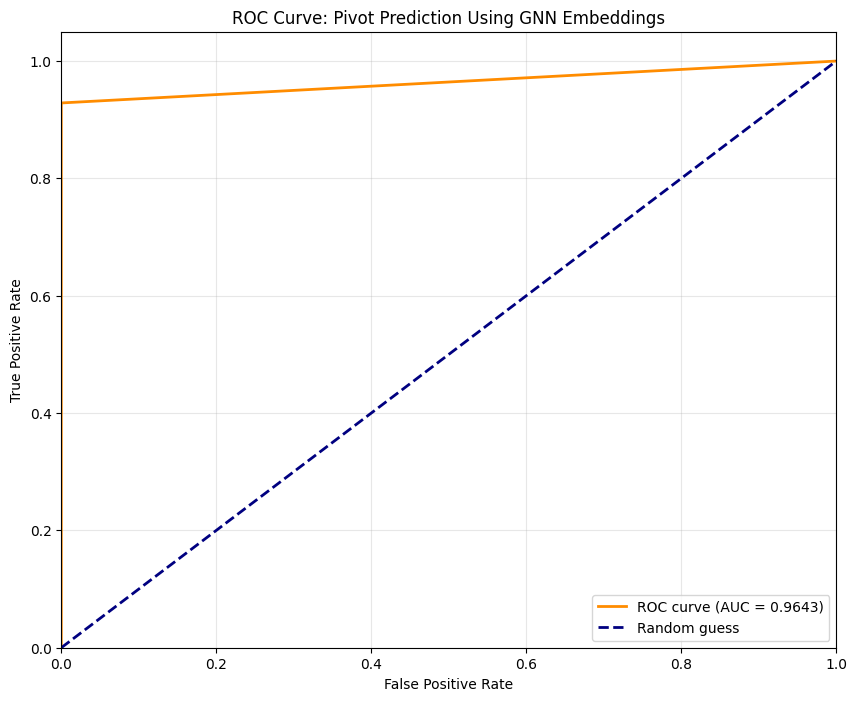

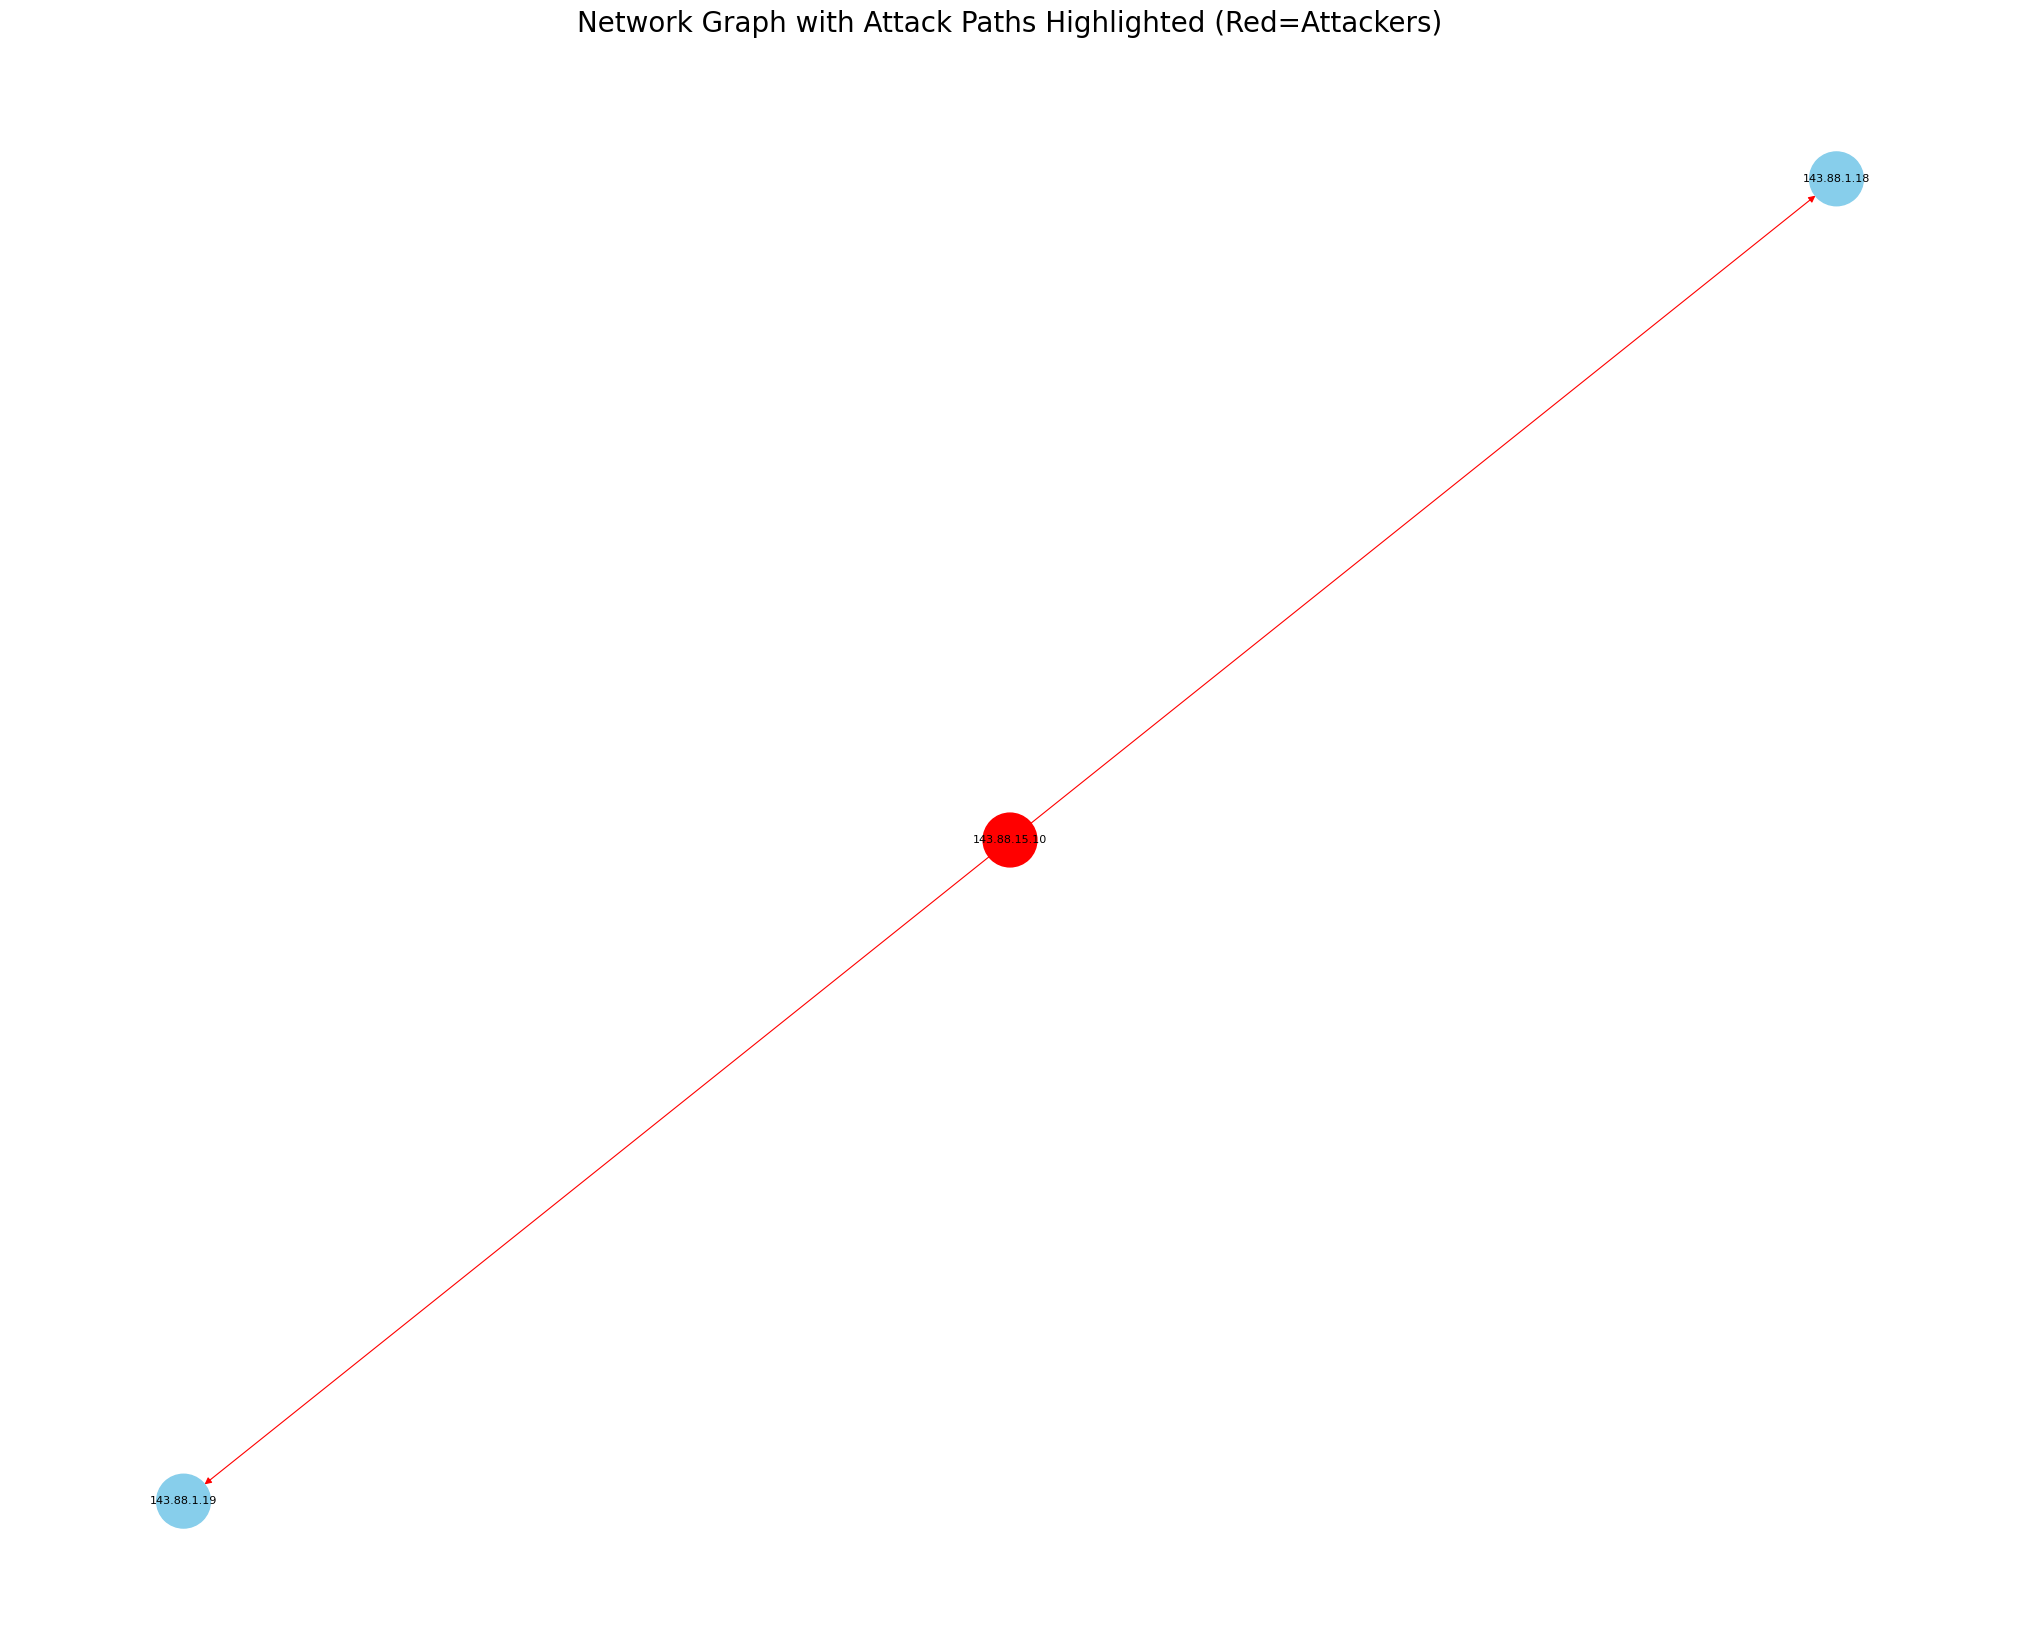

In [1]:
from CART import AnalysisController

controller = AnalysisController(
    uri="bolt://localhost:7687",
    user="neo4j",
    password="ubuntuubuntu",
    database="neo4j"  # Community Edition uses default database
)

# Build the database (downloads data and writes to Neo4j)
#controller.ThesisAnalyzer.build_database(rebuild=True)

# Run analysis
controller.ThesisAnalyzer.run_analysis()

In [2]:

JSON_OUTPUT_FILE = "structural_pivots.json"


controller.StructuralPivotAnalyzer.run_analysis(output_filepath=JSON_OUTPUT_FILE)

reporter = AnalysisController.create_report_generator(filepath=JSON_OUTPUT_FILE)
reporter.generate_report()

✓ Successfully connected to the Neo4j database.

STRUCTURAL PIVOT CANDIDATE ANALYSIS
--- Finding all A -> B -> C structural and temporal paths ---
✓ Found 500,000 candidates in 42.50 seconds.
--- Saving 500,000 candidates to structural_pivots.json ---
✓ Data successfully written.
✓ Neo4j connection closed.
--- Loading data from structural_pivots.json ---
✓ Loaded 500,000 records into DataFrame.

PIVOT PREDICTION VALIDATION REPORT

--- MODEL PERFORMANCE ---
  Total Structural Candidates Found: 500,000
  Verified True Pivots (A->B and B->C were attacks): 500,000
  Precision of Structural Prediction: 100.00%

--- ANALYSIS OF VERIFIED PIVOTS ---
  Timing (Compromise to Pivot):
    Mean: 292.44 hours
    Median: 336.25 hours
    Min: 0.00 hours
    Max: 594.78 hours

  Most Common Pivot Nodes:
pivot_ip
143.88.15.10    500000

  Most Common Tactic Transitions (Compromise → Pivot):
compromise_tactic  pivot_tactic     
Reconnaissance     Credential Access    472869
                   Reconnais

✓ Successfully connected to the Neo4j database.

KILL CHAIN EXPLORATORY ANALYSIS

--- BASIC STATISTICS ---
  Total IPs: 106
  Total Connections: 500,000
  Attack Connections: 500,000 (100.0%)
  Unique Attackers: 15
  Unique Victims: 105

  Attack Tactics Distribution:
    Credential Access: 465,173
    Reconnaissance: 29,432
    Defense Evasion: 3,034
    Initial Access: 2,066
    Exfiltration: 295

--- FINDING PIVOT NODES (Victim → Attacker Transitions) ---
  ✓ Found 14 unique pivot IPs
  ✓ Found 14 unique pivot transitions (first compromise → first attack)

  Pivot Activity Summary:
    Most active pivot: 143.88.3.11
      Times compromised: 208
      Subsequent attacks launched: 60,907

--- PIVOT TIMING ANALYSIS ---
  Time Between Compromise and Attack:
    Mean: 0.61 hours
    Median: 0.19 hours
    Min: 0.09 hours
    Max: 5.50 hours

  Pivot Attack Timeline:
    Within 24 hours: 14 (100.0%)
    Within 48 hours: 14 (100.0%)
    Within 1 week: 14 (100.0%)

--- PIVOT TACTIC ANALYSIS

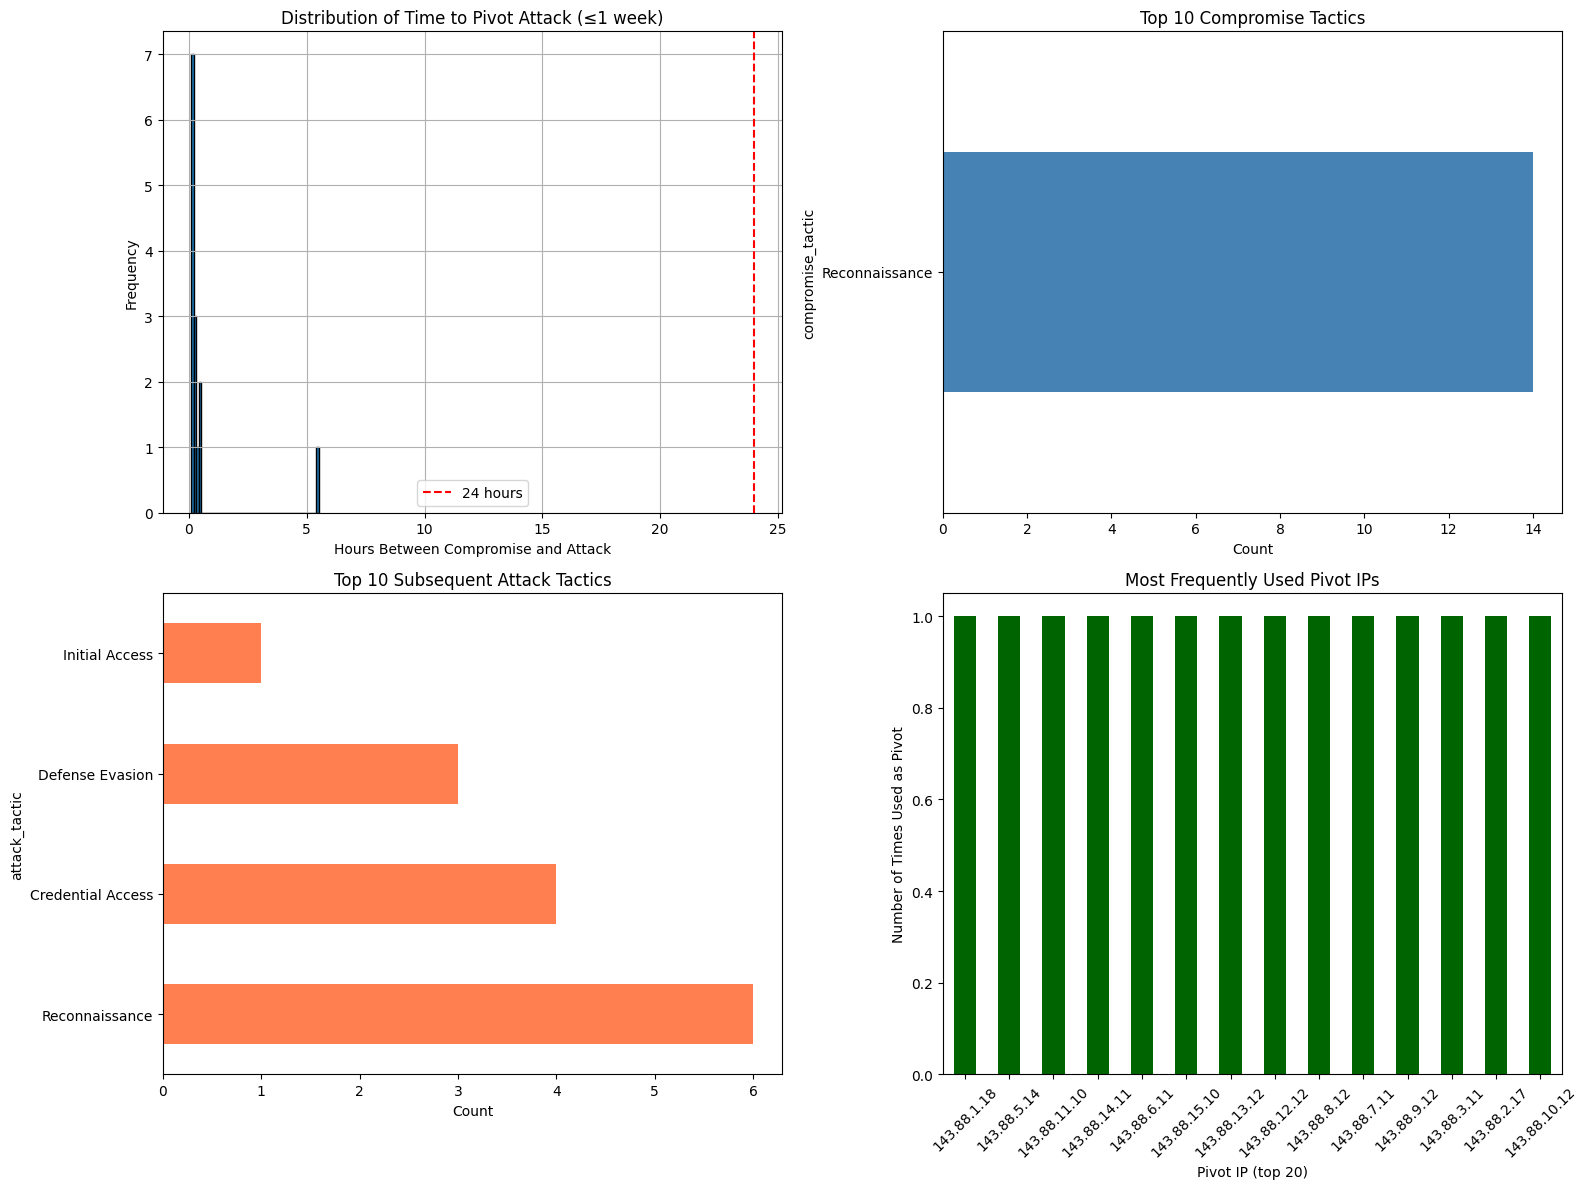

In [3]:
controller.KillChainAnalyzer.run_full_analysis()